In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load diabetes dataset
diabetes = load_diabetes()

# Use only one feature: BMI (index 2)
X = diabetes.data[:, 2]  # BMI
y = diabetes.target      # Target: disease progression

print("Sample Input (BMI):", X[:5])
print("Sample Output (Progression):", y[:5])

Sample Input (BMI): [ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
Sample Output (Progression): [151.  75. 141. 206. 135.]


In [25]:
# Add bias term (intercept)
X_b = np.c_[np.ones((len(X), 1)), X]

# Hyperparameters
learning_rate = 0.1
n_iterations = 1000
m = len(y)

# Initialize theta randomly
theta = np.random.randn(2)
print("Initial θ:", theta)

Initial θ: [-0.03044515 -0.66229833]


In [26]:
# Add bias term (intercept)
X_b = np.c_[np.ones((len(X), 1)), X]

# Hyperparameters
learning_rate = 0.1
n_iterations = 1000
m = len(y)

# Initialize theta randomly
theta = np.random.randn(2)
print("Initial θ:", theta)

Initial θ: [ 1.43395294 -1.08263676]


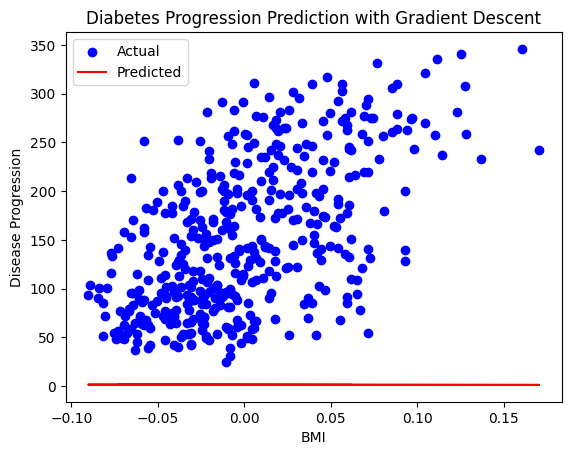

In [27]:
# Plot actual vs predicted
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, X_b.dot(theta), color='red', label='Predicted')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('Diabetes Progression Prediction with Gradient Descent')
plt.legend()
plt.show()

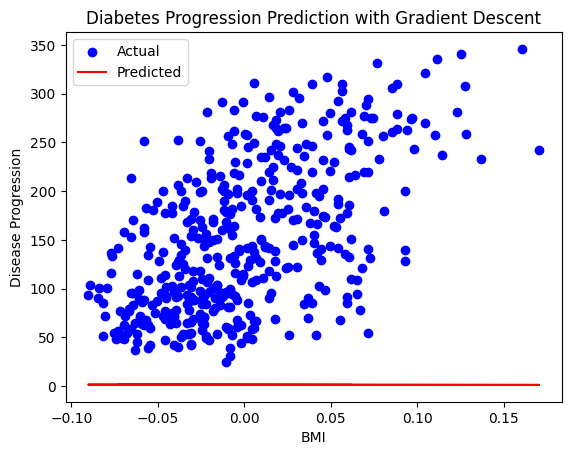

In [28]:
# Plot actual vs predicted
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, X_b.dot(theta), color='red', label='Predicted')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('Diabetes Progression Prediction with Gradient Descent')
plt.legend()
plt.show()



---

# 📘 Gradient Descent — Mathematical Explanation

We are trying to fit a **linear model**:

$$
\hat{y}^{(i)} = \theta_0 + \theta_1 x^{(i)}
$$

Where:
- $ x^{(i)} $: input feature (e.g., BMI of person $ i $)
- $ \hat{y}^{(i)} $: predicted output (e.g., disease progression for person $ i $)
- $ \theta_0, \theta_1 $: parameters (weights) we want to learn

---

## 1️⃣ Step 1: Cost Function

We define a **cost function** to measure how far off our predictions are from actual values. We use **Mean Squared Error (MSE)**:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2
$$

Substitute $ \hat{y}^{(i)} = \theta_0 + \theta_1 x^{(i)} $:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \theta_0 + \theta_1 x^{(i)} - y^{(i)} \right)^2
$$

Our goal is to **minimize this cost function** by adjusting $ \theta_0 $ and $ \theta_1 $.

---

## 2️⃣ Step 2: Gradient of the Cost Function

To minimize $ J(\theta) $, we compute the **partial derivatives** with respect to each parameter:

### Derivative w.r.t $ \theta_0 $:

$$
\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} \left( \theta_0 + \theta_1 x^{(i)} - y^{(i)} \right)
$$

### Derivative w.r.t $ \theta_1 $:

$$
\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} \left( \theta_0 + \theta_1 x^{(i)} - y^{(i)} \right) x^{(i)}
$$

These gradients tell us how much to change each weight to reduce error.

---

## 3️⃣ Step 3: Update Rule (Gradient Descent)

At each step, we update the weights using:

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{\partial J}{\partial \theta_0}
$$
$$
\theta_1 := \theta_1 - \alpha \cdot \frac{\partial J}{\partial \theta_1}
$$

Where:
- $ \alpha $: learning rate (step size)
- $ := $: means "update with"

This is repeated for many iterations until the cost stops decreasing.

---

## 4️⃣ Step 4: Vectorized Form (Optional but Efficient)

Instead of computing $ \theta_0 $ and $ \theta_1 $ separately, we can represent them as a vector:

$$
\mathbf{\theta} =
\begin{bmatrix}
\theta_0 \\
\theta_1
\end{bmatrix}, \quad
\mathbf{X} =
\begin{bmatrix}
1 & x^{(1)} \\
1 & x^{(2)} \\
\vdots & \vdots \\
1 & x^{(m)}
\end{bmatrix}, \quad
\mathbf{y} =
\begin{bmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(m)}
\end{bmatrix}
$$

Then:

$$
\text{Predictions: } \hat{\mathbf{y}} = \mathbf{X} \mathbf{\theta}
$$
$$
\text{Error: } \mathbf{e} = \hat{\mathbf{y}} - \mathbf{y}
$$
$$
\text{Gradient: } \nabla J(\theta) = \frac{2}{m} \mathbf{X}^\top \mathbf{e}
$$
$$
\text{Update: } \mathbf{\theta} := \mathbf{\theta} - \alpha \cdot \nabla J(\theta)
$$

This is exactly what we implemented in code earlier.

---

## 5️⃣ Step 5: Prediction Using Final Weights

Once we have learned $ \theta_0 $ and $ \theta_1 $, we can make predictions for new inputs:

$$
\hat{y}_{\text{new}} = \theta_0 + \theta_1 x_{\text{new}}
$$

Or in vector form:

$$
\hat{y}_{\text{new}} = [1 \; x_{\text{new}}] \cdot \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix}
$$

---

## ✅ Summary Table (Mathematical View)

| Step | Formula |
|------|---------|
| Model | $ \hat{y}^{(i)} = \theta_0 + \theta_1 x^{(i)} $ |
| Cost | $ J(\theta) = \frac{1}{2m} \sum (\hat{y}^{(i)} - y^{(i)})^2 $ |
| Gradients | $ \frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum (\hat{y}^{(i)} - y^{(i)}) $ <br> $ \frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum (\hat{y}^{(i)} - y^{(i)}) x^{(i)} $ |
| Update | $ \theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j} $ |
| Prediction | $ \hat{y}_{\text{new}} = \theta_0 + \theta_1 x_{\text{new}} $ |

---

## 🎯 Final Answer:

> Gradient Descent finds the best weights $ \theta_0 $ and $ \theta_1 $ by iteratively minimizing the cost function using its gradient.
>
> The final weights are then used to make predictions on new data.
>
> $$
> \boxed{
> \text{Model: } \hat{y} = \theta_0 + \theta_1 x \quad \text{Update: } \theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}
> }
> $$

